# Linear Multi-Sensor Fusion: Odometry + Camera

这个 notebook 是 Day 4 的代码框架。目标是在 Day 3 的二维 KF 基础上，加入两个具有不同误差特性的传感器：

- Odometry：高频、连续，但包含 bias 和 noise，会累计漂移。
- Camera：低频、带噪声，并且可能 dropout，但不会持续累计漂移。
- Kalman fusion：odometry 用于 predict，camera 可用时用于 update。

最终输出：

- `figures/linear_fusion_trajectory.png`
- `figures/linear_fusion_position_error.png`
- `figures/camera_dropout_timeline.png`
- `results/linear_fusion_rmse.csv`

今天只做线性 KF，不加入 `theta`、EKF 或 Jacobian。

## 1. 参考内容

优先参考：

1. `scripts/02_kf_2d_position_velocity.py`：复用 ground truth、KF、RMSE 和绘图结构。
2. `notes/day04_linear_multisensor_fusion.md`：查看每一步的详细要求。
3. `source/filterpy/filterpy/kalman/kalman_filter.py`：只搜索 `def predict` 和 `def update`。
4. `source/filterpy/filterpy/kalman/tests/test_sensor_fusion.py`：只看 predict/update 的调用顺序。

完成顺序：

```text
ground truth
-> odometry velocity
-> odometry-only trajectory
-> sparse camera measurements + dropout
-> Kalman fusion
-> plots and RMSE
```

## 2. 导入依赖和设置输出路径

这一部分沿用 Day 3 notebook。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('e:/申博材料/机器人相关学习/阶段一_基础补齐/01_FilterPy状态估计_移动机器人定位')

## 3. 设置实验参数

先使用建议参数跑通。不要同时修改多组参数。

需要理解：

- `odometry_bias` 方向固定，会累计成漂移。
- `odometry_noise_std` 产生每一步随机波动。
- `camera_interval=5` 表示每 5 步尝试一次 camera 测量。
- `dropout_probability=0.25` 表示尝试测量时有 25% 概率丢失。

In [ ]:
dt = 1.0
num_steps = 120
initial_position = np.array([0.0, 0.0])
true_velocity = np.array([1.0, 0.5])
initial_velocity_guess = np.array([0.0, 0.0])

odometry_bias = np.array([0.05, -0.03])
odometry_noise_std = 0.08

camera_noise_std = 2.0
camera_interval = 5
dropout_probability = 0.25 #相机丢失概率 25%测量失败

process_noise_var = 0.05
initial_covariance = 100.0
random_seed = 42

rng = np.random.default_rng(random_seed)

## 4. 生成 Ground Truth

复用 Day 3 的二维匀速轨迹。

输出形状：

- `times`: `(num_steps,)`
- `true_positions`: `(num_steps, 2)`

In [3]:
def generate_ground_truth(num_steps, dt, initial_position, true_velocity):
    times = np.arange(num_steps) * dt
    true_positions = initial_position + times[:, None] * true_velocity
    return times, true_positions


times, true_positions = generate_ground_truth(
    num_steps=num_steps,
    dt=dt,
    initial_position=initial_position,
    true_velocity=true_velocity,
)

print("true_positions shape:", true_positions.shape)
true_positions[:5]

true_positions shape: (120, 2)


array([[0. , 0. ],
       [1. , 0.5],
       [2. , 1. ],
       [3. , 1.5],
       [4. , 2. ]])

## 5. 模拟 Odometry Velocity

函数目标：

```text
odometry_velocity = true_velocity + bias + random_noise
```

输出：`odometry_velocities`，形状 `(num_steps, 2)`。

参考：Day 3 的 `add_position_measurement_noise()`，但这里给速度加噪声。

In [26]:
def simulate_odometry(true_velocity, num_steps, bias, noise_std, rng):
    # TODO 1: 生成 shape=(num_steps, 2) 的高斯噪声
    noise = rng.normal(
        loc = 0.0,
        scale = noise_std,
        size = (num_steps, 2)
    )
    # TODO 2: 将 true_velocity、bias 和 noise 相加
    odometry_velocities = true_velocity + bias + noise
    # TODO 3: 返回 odometry_velocities
    return odometry_velocities


# 完成函数后取消下面代码的注释
odometry_velocities = simulate_odometry(
    true_velocity=true_velocity,
    num_steps=num_steps,
    bias=odometry_bias,
    noise_std=odometry_noise_std,
    rng=rng,
)
print("odometry_velocities shape:", odometry_velocities.shape)
odometry_velocities[:5]

odometry_velocities shape: (120, 2)


array([[0.99907078, 0.51329053],
       [1.11103412, 0.50584795],
       [0.91515221, 0.51304276],
       [0.96725536, 0.48882209],
       [0.93610125, 0.50570577]])

## 6. 积分得到 Odometry-Only Trajectory

函数目标：只使用 odometry velocity 积分位置。

```text
position[i] = position[i-1] + odometry_velocity[i] * dt
```

预期：轨迹开始接近 ground truth，随后因为 bias 逐渐漂移。

注意：明确第 0 步是初始位置，避免索引错一位。

In [27]:
def integrate_odometry(initial_position, odometry_velocities, dt):
    # TODO 1: 创建 shape=(num_steps, 2) 的 positions
    positions = np.zeros(
        (odometry_velocities.shape[0], 2)
    )
    # TODO 2: 设置 positions[0] = initial_position
    positions[0] = initial_position
    # TODO 3: 从 i=1 开始积分 odometry velocity
    for i in range(
        1, odometry_velocities.shape[0]
    ):
        positions[i] = positions[i - 1] + odometry_velocities[i - 1] * dt
    # TODO 4: 返回 positions
    return positions


# 完成函数后取消下面代码的注释
odometry_positions = integrate_odometry(
    initial_position=initial_position,
    odometry_velocities=odometry_velocities,
    dt=dt,
)
print(odometry_positions)
print("odometry_positions shape:", odometry_positions.shape)
print("odometry_velocities shape:", odometry_velocities.shape)

[[  0.           0.        ]
 [  0.99907078   0.51329053]
 [  2.1101049    1.01913848]
 [  3.02525711   1.53218123]
 [  3.99251247   2.02100332]
 [  4.92861371   2.52670909]
 [  5.9140858    2.89409832]
 [  7.02119141   3.38342988]
 [  8.02207327   3.96952419]
 [  9.03682107   4.44209281]
 [ 10.10833415   4.86251953]
 [ 11.19602505   5.28984334]
 [ 12.21309399   5.86885475]
 [ 13.1798471    6.14583233]
 [ 14.35872206   6.81977856]
 [ 15.37630052   7.13483152]
 [ 16.4014618    7.58193368]
 [ 17.43626789   7.96286264]
 [ 18.53263279   8.47482323]
 [ 19.46308034   9.00075897]
 [ 20.67729513   9.4845158 ]
 [ 21.70030912   9.94315554]
 [ 22.79952966  10.27470181]
 [ 23.86268092  10.71346469]
 [ 25.06050692  11.16953088]
 [ 26.24393793  11.55123162]
 [ 27.34091866  12.04678364]
 [ 28.32139488  12.53097533]
 [ 29.46839639  12.97507199]
 [ 30.38303938  13.44366697]
 [ 31.36084553  13.88627969]
 [ 32.40431851  14.21982752]
 [ 33.32506584  14.72839286]
 [ 34.33324835  14.99321332]
 [ 35.44603587

## 7. 先检查 Odometry Drift

在加入 camera 和 KF 前，先画 `ground truth vs odometry only`。

检查：

- odometry 是否从初始位置开始；
- 偏差是否随时间增大；
- 如果没有明显漂移，检查 bias 和积分循环。

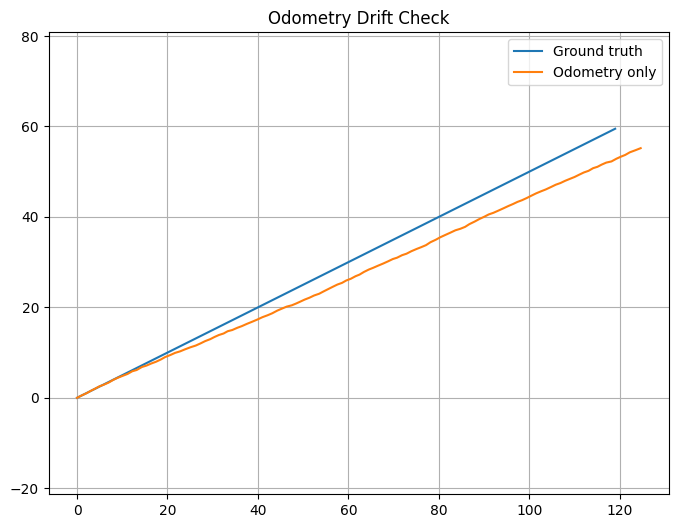

In [28]:
# 完成前两节后取消注释
plt.figure(figsize=(8, 6))
plt.plot(true_positions[:, 0], true_positions[:, 1], label="Ground truth")
plt.plot(odometry_positions[:, 0], odometry_positions[:, 1], label="Odometry only")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Odometry Drift Check")
plt.show()

## 8. 模拟低频 Camera Measurement 和 Dropout

输出：

- `camera_measurements`: `(num_steps, 2)`，无测量位置保留 `NaN`。
- `camera_available`: `(num_steps,)` 的布尔数组。

规则：

1. 只有 `i % camera_interval == 0` 时才尝试测量。
2. 使用随机数决定本次是否 dropout。
3. 有效测量等于 ground truth 加 camera noise。
4. 丢帧时不要填 `[0, 0]`。

In [31]:
def simulate_camera_measurements(true_positions, noise_std, interval,
                                 dropout_probability, rng):
    num_steps = len(true_positions)
    camera_measurements = np.full((num_steps, 2), np.nan)
    camera_available = np.zeros(num_steps, dtype=bool)

    # TODO 1: 遍历所有时间步
    for i in range(num_steps):
        if i % interval == 0:
    # TODO 2: 只在采样时刻尝试产生 measurement
            if rng.random() > dropout_probability:
    # TODO 3: 使用 rng.random() 判断是否 dropout
                camera_measurements[i] = true_positions[i] + rng.normal(
                    loc=0.0,
                    scale=noise_std,
                    size=2
                )
    # TODO 4: 有效时加入二维高斯位置噪声并设置 mask=True
                camera_available[i] = True
    return camera_measurements, camera_available


# 完成函数后取消下面代码的注释
camera_measurements, camera_available = simulate_camera_measurements(
    true_positions=true_positions,
    noise_std=camera_noise_std,
    interval=camera_interval,
    dropout_probability=dropout_probability,
    rng=rng,
)
print("valid camera measurements:", camera_available.sum())
print("camera_measurements shape:", camera_measurements.shape)

valid camera measurements: 20
camera_measurements shape: (120, 2)


## 9. 创建线性 Fusion Kalman Filter

状态仍然是：

`x = [px, py, vx, vy]`

Camera 观测仍然是：

`z = [measured_px, measured_py]`

与 Day 3 的主要区别不在矩阵，而在循环：odometry 每步参与预测，camera 只在可用时 update。

参考 Day 3 的 `create_2d_kalman_filter()`。

In [ ]:
def create_fusion_filter(dt, initial_position, initial_velocity,
                         camera_noise_std, process_noise_var,
                         initial_covariance):
    kf = KalmanFilter(dim_x=4, dim_z=2)

    # TODO 1: 设置 kf.x = [px, py, vx, vy]
    kf.x = np.array([
        initial_position[0],
        initial_position[1],
        initial_velocity[0],
        initial_velocity[1]
    ])
    # TODO 2: 设置 4x4 状态转移矩阵 F
    kf.F = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    # TODO 3: 设置 2x4 观测矩阵 H
    kf.H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])
    # TODO 4: 设置 P、Q、R
    kf.P = np.eye(4) * initial_covariance
    kf.Q = np.eye(4) * process_noise_var
    kf.R = np.eye(2) * (camera_noise_std ** 2)

    return kf



## 10. 运行线性多传感器融合

每一步的核心逻辑：

```python
kf.x[2:4] = odometry_velocities[i]
kf.predict()

if camera_available[i]:
    kf.update(camera_measurements[i])
```

需要保存：

- 每一步 fused state；
- 每一步是否执行 camera update；
- 可选：camera update 前后的误差，用于观察修正效果。

In [ ]:
def run_linear_sensor_fusion(odometry_velocities, camera_measurements,
                             camera_available, dt, initial_position,
                             initial_velocity, camera_noise_std,
                             process_noise_var, initial_covariance):
    # TODO 1: 调用 create_fusion_filter()
    kf = create_fusion_filter(
        dt=dt,
        initial_position=initial_position,
        initial_velocity=initial_velocity,
        camera_noise_std=camera_noise_std,
        process_noise_var=process_noise_var,
        initial_covariance=initial_covariance
    )
    # TODO 2: 创建 fused_states，shape=(num_steps, 4)
    fused_states = np.zeros(
        (num_steps, 4)
    )
    # TODO 3: 遍历时间步
    for i in range(num_steps):
    # TODO 4: 将当前 odometry velocity 放入状态速度分量
        kf.x[2:4] = odometry_velocities[i]
    # TODO 5: 调用 predict()
        if i > 0:
            kf.predict()
    # TODO 6: camera 可用时调用 update()，不可用时跳过
        if camera_available[i]:
            kf.update(camera_measurements[i])
    # TODO 7: 保存 kf.x
        fused_states[i] = kf.x
    # TODO 8: 返回 fused_states
    return fused_states


## 11. 检查数组形状和有效测量数量

完成融合函数后，应该得到：

```text
true_positions       (120, 2)
odometry_velocities  (120, 2)
odometry_positions   (120, 2)
camera_measurements  (120, 2)
camera_available     (120,)
fused_states         (120, 4)
```

In [34]:
# 完成前面函数后取消注释
fused_states = run_linear_sensor_fusion(
    odometry_velocities=odometry_velocities,
    camera_measurements=camera_measurements,
    camera_available=camera_available,
    dt=dt,
    initial_position=initial_position,
    initial_velocity=initial_velocity_guess,
    camera_noise_std=camera_noise_std,
    process_noise_var=process_noise_var,
    initial_covariance=initial_covariance,
)

print(fused_states)
print("fused_states shape:", fused_states.shape)
print("camera update count:", camera_available.sum())

[[ 4.31330829e+00 -3.69202534e-03  9.99070777e-01  5.13290529e-01]
 [ 5.42434241e+00  5.02155924e-01  1.11103412e+00  5.05847949e-01]
 [ 6.33949463e+00  1.01519868e+00  9.15152215e-01  5.13042755e-01]
 [ 7.30674998e+00  1.50402077e+00  9.67255356e-01  4.88822089e-01]
 [ 8.24285123e+00  2.00972654e+00  9.36101245e-01  5.05705772e-01]
 [ 8.23533403e+00  2.76144069e+00  7.87119637e-01  4.44159230e-01]
 [ 9.34243964e+00  3.25077225e+00  1.10710561e+00  4.89331562e-01]
 [ 1.03433215e+01  3.83686656e+00  1.00088186e+00  5.86094308e-01]
 [ 1.13580693e+01  4.30943517e+00  1.01474781e+00  4.72568614e-01]
 [ 1.24295824e+01  4.72986189e+00  1.07151308e+00  4.20426725e-01]
 [ 1.03041330e+01  4.96078279e+00  6.34400465e-01  3.99616474e-01]
 [ 1.13212020e+01  5.53979420e+00  1.01706893e+00  5.79011411e-01]
 [ 1.22879551e+01  5.81677178e+00  9.66753116e-01  2.76977574e-01]
 [ 1.34668300e+01  6.49071801e+00  1.17887496e+00  6.73946236e-01]
 [ 1.44844085e+01  6.80577097e+00  1.01757846e+00  3.15052957e

## 12. 计算 RMSE

需要计算：

- odometry-only RMSE：全部时间步；
- camera RMSE：只在 `camera_available=True` 的时刻；
- KF fusion RMSE：全部时间步。

注意：不能把 camera 的 NaN 行放入 RMSE。

In [35]:
def compute_position_rmse(estimated_positions, true_positions):
    position_errors = estimated_positions - true_positions
    squared_distances = np.sum(position_errors ** 2, axis=1)
    mean_squared_distance = np.mean(squared_distances)
    rmse = np.sqrt(mean_squared_distance)
    return rmse


# TODO 1: 计算 odometry_rmse
odometry_rmse = compute_position_rmse(
    estimated_positions = odometry_positions, 
    true_positions = true_positions,
)
# TODO 2: 使用 camera_available mask 计算 camera_rmse
camera_rmse = compute_position_rmse(
    estimated_positions = camera_measurements[camera_available], 
    true_positions = true_positions[camera_available]
)
# TODO 3: 使用 fused_states[:, :2] 计算 fusion_rmse
fusion_rmse = compute_position_rmse(
    estimated_positions = fused_states[:, :2], 
    true_positions = true_positions
)
# TODO 4: 打印三个 RMSE
print(f"Odometry RMSE: {odometry_rmse}")
print(f"Camera RMSE: {camera_rmse}")
print(f"Fusion RMSE: {fusion_rmse}")

Odometry RMSE: 4.096518020049454
Camera RMSE: 2.3945823033214935
Fusion RMSE: 2.0672395279609517


## 13. 保存 RMSE 表格

目标文件：`results/linear_fusion_rmse.csv`

建议列：

```csv
method,position_rmse,evaluation_steps
odometry_only,...,120
camera_measurement,...,...
kalman_fusion,...,120
```

如果 CSV 正在 Excel 中打开，保存时会出现 `PermissionError`。

In [36]:
# TODO: 完成 RMSE 计算后取消注释并补全变量
rmse_table = pd.DataFrame({
    "method": ["odometry_only", "camera_measurement", "kalman_fusion"],
    "position_rmse": [odometry_rmse, camera_rmse, fusion_rmse],
    "evaluation_steps": [num_steps, int(camera_available.sum()), num_steps],
})
rmse_output_path = RESULTS_DIR / "linear_fusion_rmse.csv"
rmse_table.to_csv(rmse_output_path, index=False)
rmse_table

,method,position_rmse,evaluation_steps
0,odometry_only,4.096518,120
1,camera_measurement,2.394582,20
2,kalman_fusion,2.067240,120


## 14. 绘制四类轨迹

图中必须包含：

- Ground truth
- Odometry only
- Camera measurements
- KF fused estimate

Camera 只画有效测量点：`camera_measurements[camera_available]`。

输出：`figures/linear_fusion_trajectory.png`

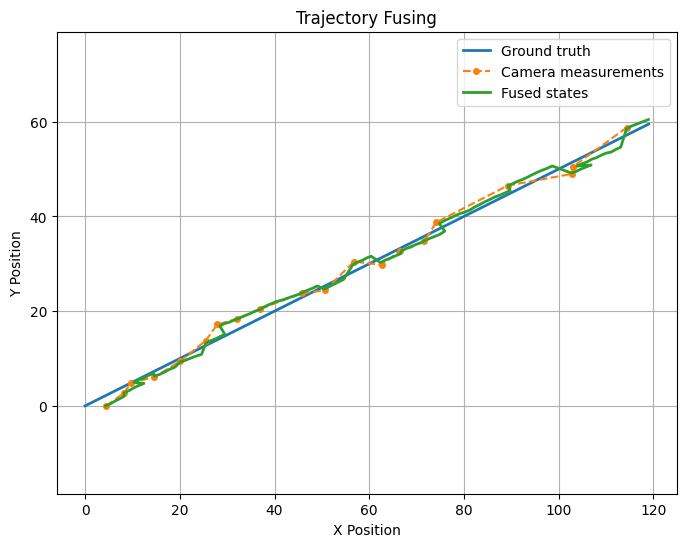

In [43]:
def plot_fusion_trajectory(true_positions, odometry_positions,
                           camera_measurements, camera_available,
                           fused_states, output_path):
    # TODO 1: 创建 figure
    plt.figure(figsize=(8, 6))
    # TODO 2: 画 ground truth 和 odometry only
    plt.plot(
        true_positions[:, 0], 
        true_positions[:, 1], 
        linewidth = 2,
        label="Ground truth"
    )
    # TODO 3: 只画有效 camera measurements
    plt.plot(
        camera_measurements[camera_available, 0],
        camera_measurements[camera_available, 1],
        linestyle='--',
        marker='o',
        markersize=4,
        label="Camera measurements"
    )
    # TODO 4: 画 fused_states[:, 0] vs fused_states[:, 1]
    plt.plot(
        fused_states[:, 0],
        fused_states[:, 1],
        linewidth=2,
        label="Fused states"
    )
    # TODO 5: 设置 axis equal、标题、图例、网格
    plt.axis('equal')
    plt.title('Trajectory Fusing')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.legend()
    plt.grid(True)
    # TODO 6: 保存并关闭 figure
    plt.savefig(output_path)
    plt.show()


fusion_trajectory_path = (
    FIGURES_DIR / "linear_fusion_trajectory.png"
)

plot_fusion_trajectory(
    true_positions, 
    odometry_positions,
    camera_measurements, 
    camera_available,
    fused_states, 
    fusion_trajectory_path
)


## 15. 绘制位置误差和 Camera Dropout

位置误差图至少包含：

- Odometry position error
- KF fusion position error
- 有效 camera measurement error 散点

Dropout 图使用 `camera_available.astype(int)`。

输出：

- `figures/linear_fusion_position_error.png`
- `figures/camera_dropout_timeline.png`

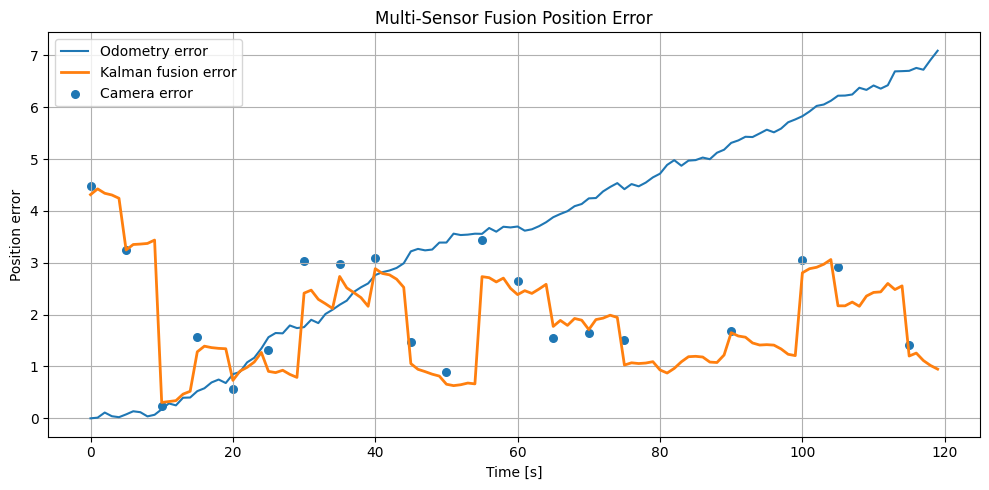

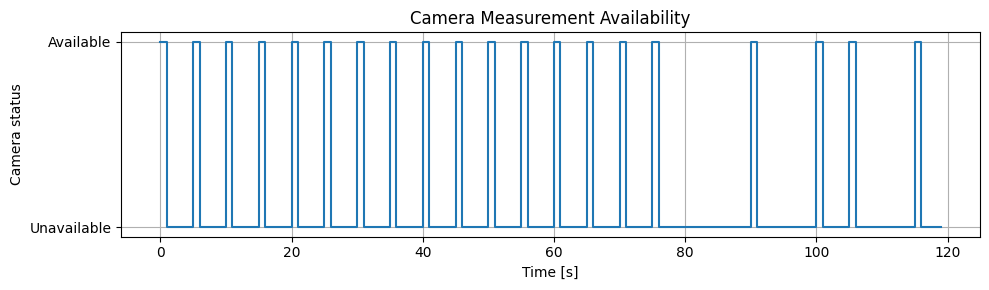

In [42]:
def plot_position_error(times, true_positions, odometry_positions,
                        camera_measurements, camera_available,
                        fused_states, output_path):
    # TODO: 计算三类有效误差并绘图
    odometry_errors = np.linalg.norm(
        odometry_positions - true_positions,
        axis=1,
    )

    fusion_errors = np.linalg.norm(
        fused_states[:, :2] - true_positions,
        axis=1,
    )

    camera_errors = np.linalg.norm(
        camera_measurements[camera_available]
        - true_positions[camera_available],
        axis=1,
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        times,
        odometry_errors,
        label="Odometry error",
    )

    plt.plot(
        times,
        fusion_errors,
        linewidth=2,
        label="Kalman fusion error",
    )

    plt.scatter(
        times[camera_available],
        camera_errors,
        s=30,
        label="Camera error",
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Position error")
    plt.title("Multi-Sensor Fusion Position Error")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_path, dpi=150)
    plt.show()

position_error_path = (
    FIGURES_DIR / "linear_fusion_position_error.png"
)

plot_position_error(
    times=times,
    true_positions=true_positions,
    odometry_positions=odometry_positions,
    camera_measurements=camera_measurements,
    camera_available=camera_available,
    fused_states=fused_states,
    output_path=position_error_path,
)


def plot_camera_dropout(times, camera_available, output_path):
    # TODO: 将 camera_available 转成 0/1 并绘制时间线
    camera_status = camera_available.astype(int)

    plt.figure(figsize=(10, 3))

    plt.step(
        times,
        camera_status,
        where="post",
    )

    plt.yticks(
        [0, 1],
        ["Unavailable", "Available"],
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Camera status")
    plt.title("Camera Measurement Availability")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(output_path, dpi=150)
    plt.show()

dropout_path = FIGURES_DIR / "camera_dropout_timeline.png"

plot_camera_dropout(
    times=times,
    camera_available=camera_available,
    output_path=dropout_path,
)

## 16. 最终验收

文件验收：

- `figures/linear_fusion_trajectory.png`
- `figures/linear_fusion_position_error.png`
- `figures/camera_dropout_timeline.png`
- `results/linear_fusion_rmse.csv`

结果验收：

- Odometry-only 轨迹随时间累计漂移。
- Camera measurements 稀疏、有噪声并包含 dropout。
- Camera 丢帧时 fused trajectory 仍连续。
- Camera 恢复后 fused error 被修正。
- KF fusion RMSE 小于 odometry-only RMSE。

## 17. 完成后转成 Python 脚本

Notebook 全部跑通后，再整理为：

`scripts/03_linear_multisensor_fusion.py`

推荐结构：

```text
generate_ground_truth()
simulate_odometry()
integrate_odometry()
simulate_camera_measurements()
create_fusion_filter()
run_linear_sensor_fusion()
compute_position_rmse()
plot_fusion_trajectory()
plot_position_error()
plot_camera_dropout()
save_rmse_table()
main()
```

优先级：先让 odometry 漂移正确，再加入 camera，最后做 KF fusion 和图表。

## 18. 学习结果记录

完成后回到 `notes/day04_linear_multisensor_fusion.md` 的第 14 节填写：

- 传感器参数
- 三类 RMSE
- dropout 区间现象
- 必答问题
- 中英文 30 秒表达

进入 EKF 前，必须能解释：

```text
odometry 如何进入 predict？
camera 如何进入 update？
camera 丢帧时为什么可以继续预测？
```